### SOME M-T Yves Roland

## Projet Churn — Partie 1 : Machine Learning
### Données tabulaires — Telco Customer Churn Dataset
---
**Pipeline :** EDA → Prétraitement → Feature Engineering → Modèles ML → Évaluation

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


##  Chargement des données

In [2]:

df = pd.read_csv('Telco Customer Churn.csv')



## Analyse exploratoire des données

In [3]:
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Conversion de la feature TotalCharges en float car nous constatons un probleme sur le type

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Valeurs manquantes après conversion :")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valeurs manquantes après conversion :
TotalCharges    11
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Detection doublons

In [7]:
df.duplicated().sum()

0

## Detection NaN

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


---
## EDA : Distribution de la variable cible

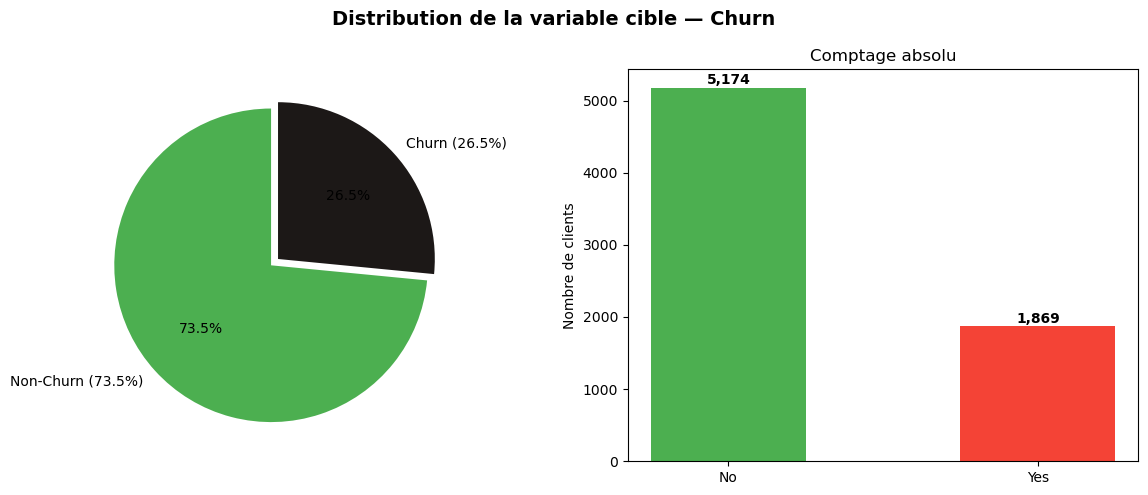

In [10]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution de la variable cible — Churn', fontsize=14, fontweight='bold')

# Camembert
axes[0].pie(
    churn_counts.values,
    labels=[f'Non-Churn ({churn_pct["No"]:.1f}%)', f'Churn ({churn_pct["Yes"]:.1f}%)'],
    colors=['#4CAF50', "#1C1817"],
    autopct='%1.1f%%', startangle=90, explode=(0, 0.06)
)

# Barplot
bars = axes[1].bar(['No', 'Yes'], churn_counts.values, color=['#4CAF50', '#F44336'], width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Comptage absolu')

plt.tight_layout()
plt.show()



---
##  EDA : Distribution des variables numériques par churn

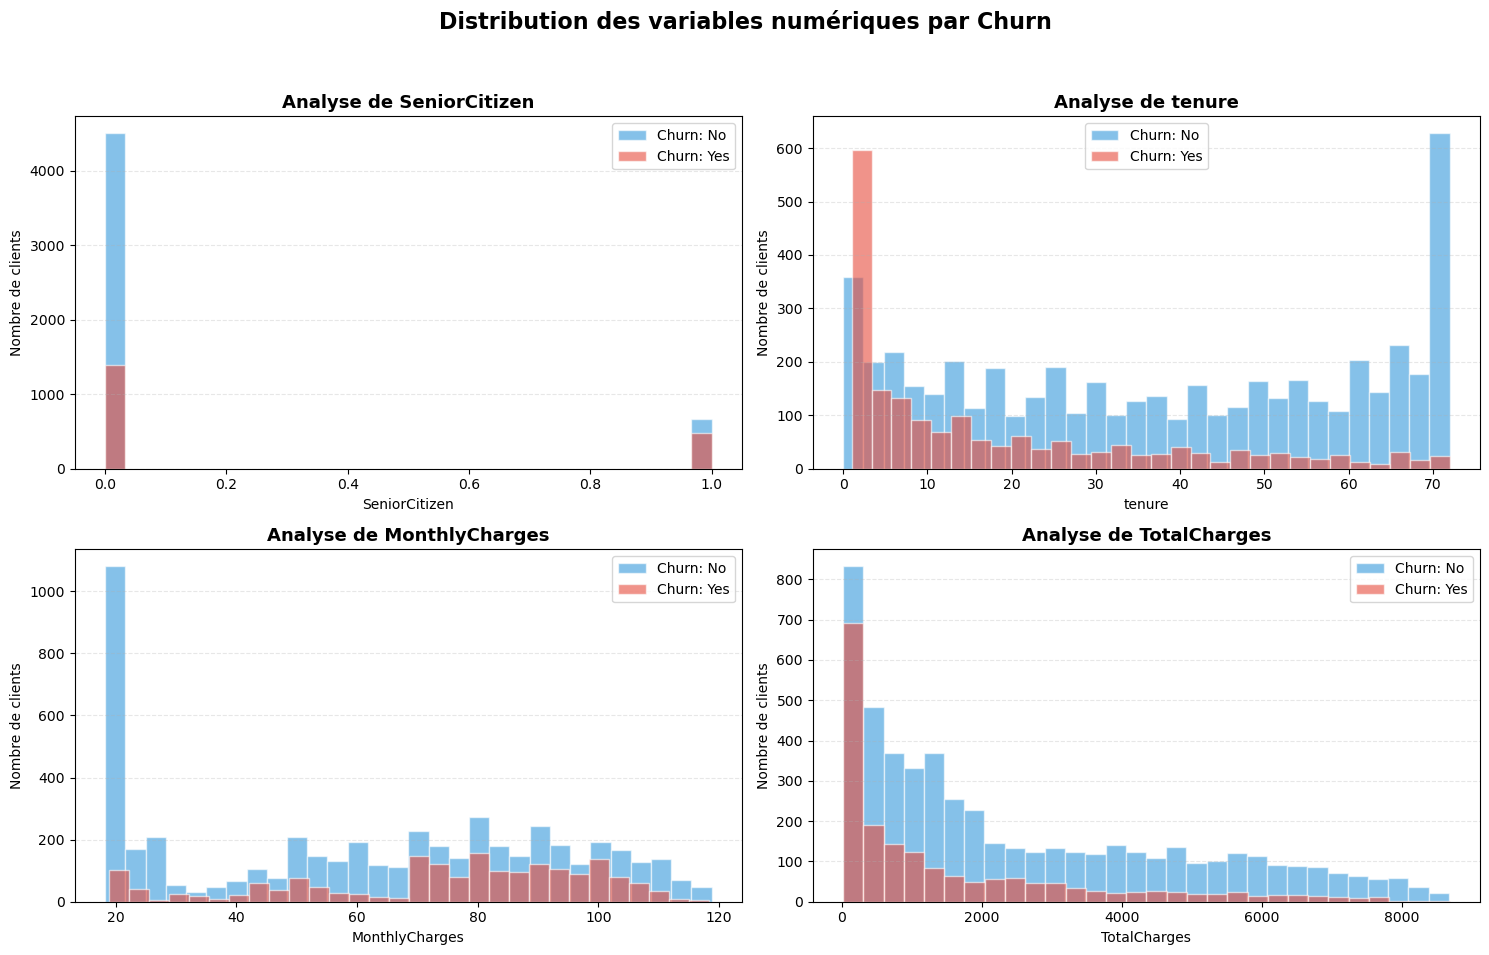

📊 Statistiques descriptives par Churn :

--- SeniorCitizen ---


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,0.13,0.33,0.0,0.0,0.0,0.0,1.0
Yes,1869.0,0.25,0.44,0.0,0.0,0.0,1.0,1.0



--- tenure ---


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0



--- MonthlyCharges ---


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35



--- TotalCharges ---


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.34,2329.46,18.80,577.83,1683.60,4264.12,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.50,703.55,2331.30,8684.80


In [44]:
import matplotlib.pyplot as plt

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# 1. Conversion de TotalCharges au cas où (souvent nécessaire sur ce dataset)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Configuration de la grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution des variables numériques par Churn', fontsize=16, fontweight='bold')

# On aplatit les axes pour la boucle
axes = axes.flatten()

# 3. Correction des clés : on utilise 'No' et 'Yes' au lieu de 0 et 1
colors = {'No': '#3498db', 'Yes': '#e74c3c'} 

for i, col in enumerate(num_cols):
    for label, grp in df.groupby('Churn'):
        axes[i].hist(
            grp[col].dropna(), 
            bins=30, 
            alpha=0.6, 
            label=f'Churn: {label}',
            color=colors.get(label, 'gray'), # .get() évite de planter si une valeur change
            edgecolor='white'
        )
    
    axes[i].set_title(f'Analyse de {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre de clients')
    axes[i].legend()
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Affichage des stats proprement
print("📊 Statistiques descriptives par Churn :")
for col in num_cols:
    print(f"\n--- {col} ---")
    display(df.groupby('Churn')[col].describe().round(2))

 ## Détection des valeurs aberrantes (IQR)

tenure : 0 outliers (0.00%)
MonthlyCharges : 0 outliers (0.00%)
TotalCharges : 0 outliers (0.00%)


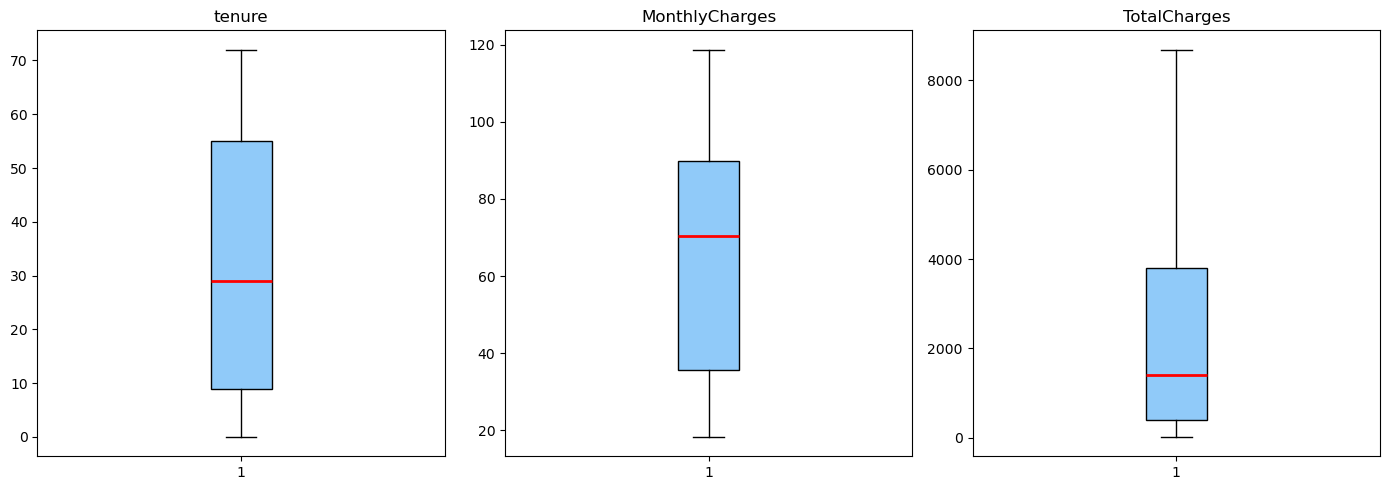

In [12]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    outliers  = df[(df[col] < borne_inf) | (df[col] > borne_sup)]
    print(f"{col} : {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#90CAF9'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange', markersize=4))
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

---
## EDA : Distribution des variables catégorielles 

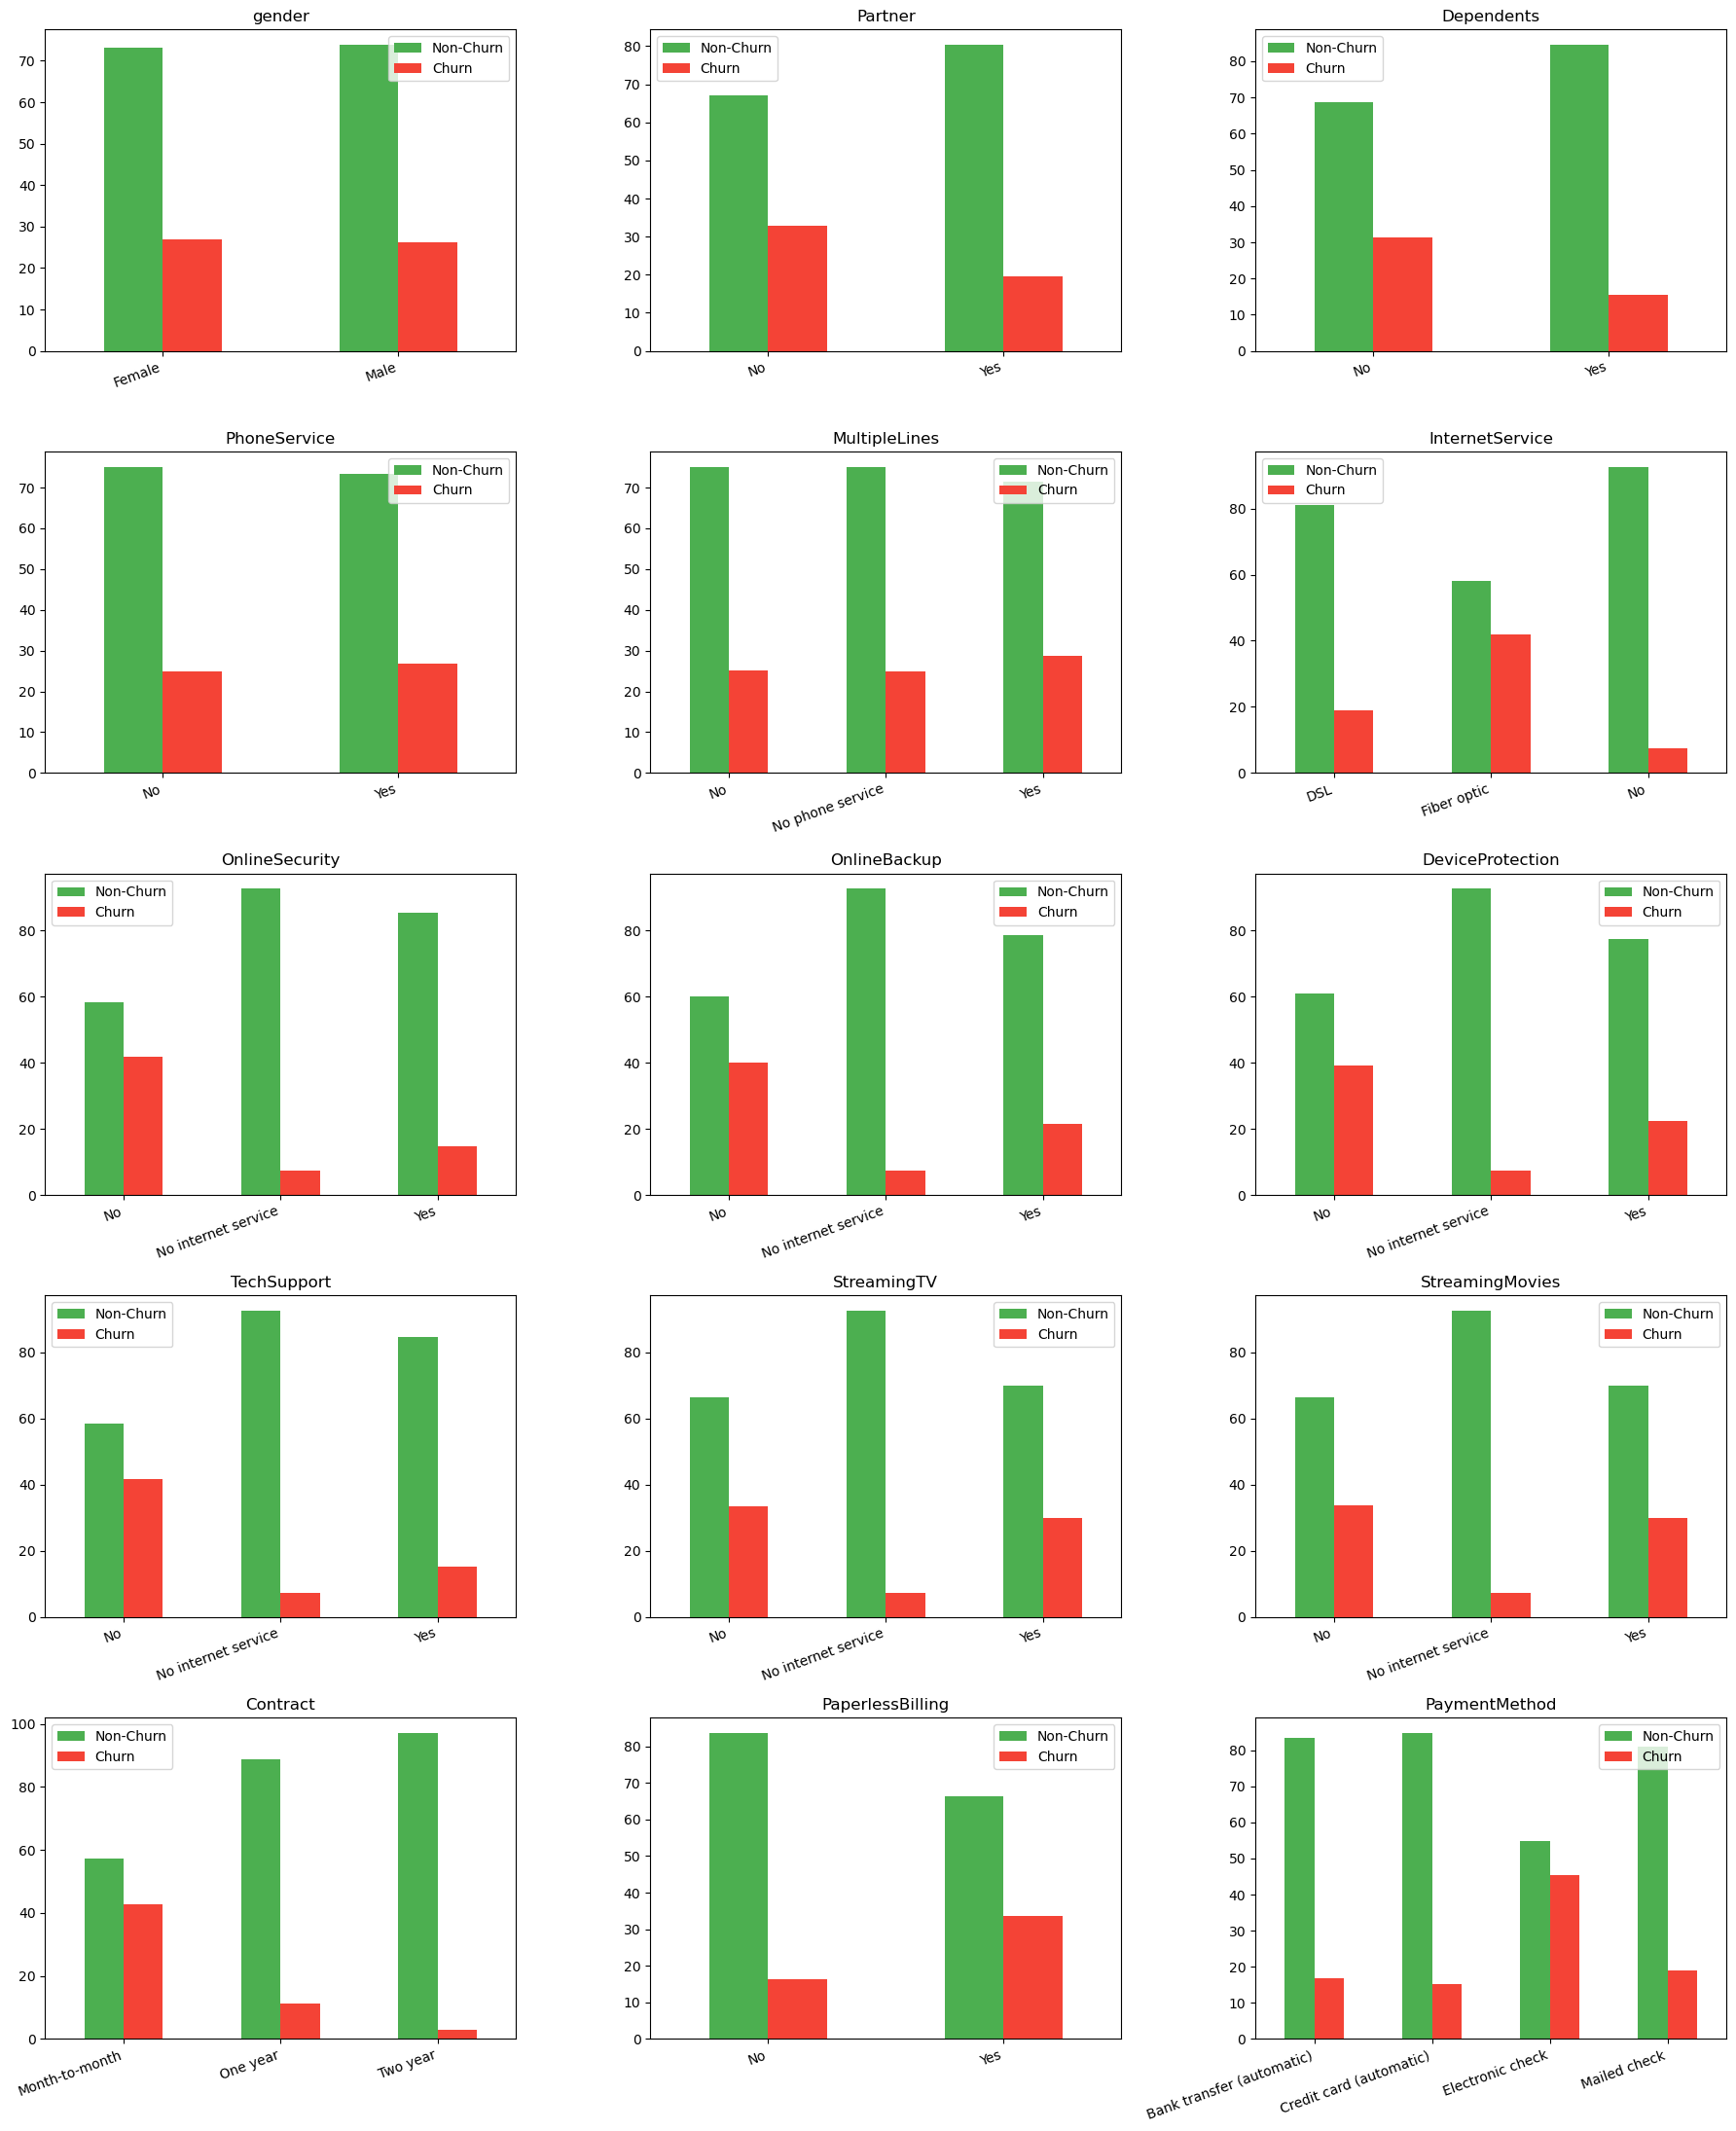

In [46]:
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
            'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'Churn']).size().unstack(fill_value=0)
    ct.div(ct.sum(axis=1), axis=0).mul(100).plot(kind='bar', ax=axes[i],
                                                   color=['#4CAF50','#F44336'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=20, ha='right')
    axes[i].legend(['Non-Churn', 'Churn'])

plt.tight_layout()
plt.show()

## Matrice de corrélations

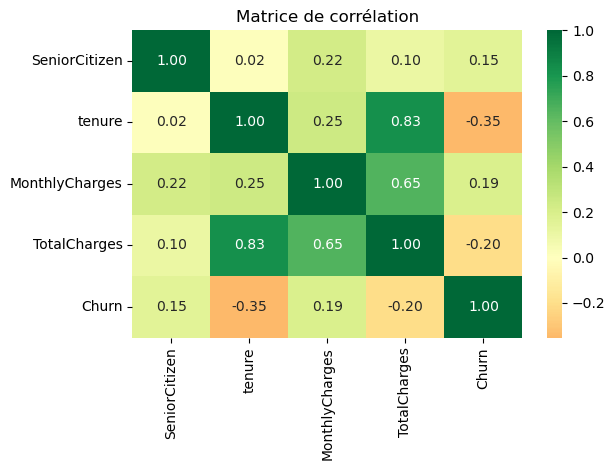

In [14]:
df_corr = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_corr['Churn'] = (df['Churn'] == 'Yes').astype(int)

sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

---
##  Prétraitement des données

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df_clean = df.copy()

# Suppression ID. On en a pas besoin pour la prédiction
df_clean.drop(columns=['customerID'], inplace=True)

# Encodage de la variable cible
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# Simplification des modalités 'No service'
for col in ['OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies','MultipleLines']:
    df_clean[col] = df_clean[col].replace({'No internet service': 'No', 
                                           'No phone service': 'No'})

X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print("Variables numériques :", num_cols)
print("Variables catégorielles :", cat_cols)

Variables numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Variables catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Gestion des valeurs manquantes: imputation par la mediane pour variables numeriques et par le mode pour categorielle

In [16]:


print("Valeurs manquantes avant imputation :")
print(X[num_cols].isnull().sum()[X[num_cols].isnull().sum() > 0])

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

X_num_imputed = imputer_num.fit_transform(X[num_cols])
print("\nAprès imputation : 0 valeur manquante")
print(pd.DataFrame(X_num_imputed, columns=num_cols).isnull().sum())

Valeurs manquantes avant imputation :
TotalCharges    11
dtype: int64

Après imputation : 0 valeur manquante
SeniorCitizen     0
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


## Encodage des variables catégorielles

In [17]:


ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_encoded = ohe.fit_transform(X[cat_cols])

print("Variables catégorielles après encodage :")
print(ohe.get_feature_names_out(cat_cols))
print(f"\nNombre de colonnes après OHE : {X_cat_encoded.shape[1]}")

Variables catégorielles après encodage :
['gender_Female' 'gender_Male' 'Partner_No' 'Partner_Yes' 'Dependents_No'
 'Dependents_Yes' 'PhoneService_No' 'PhoneService_Yes' 'MultipleLines_No'
 'MultipleLines_Yes' 'InternetService_DSL' 'InternetService_Fiber optic'
 'InternetService_No' 'OnlineSecurity_No' 'OnlineSecurity_Yes'
 'OnlineBackup_No' 'OnlineBackup_Yes' 'DeviceProtection_No'
 'DeviceProtection_Yes' 'TechSupport_No' 'TechSupport_Yes'
 'StreamingTV_No' 'StreamingTV_Yes' 'StreamingMovies_No'
 'StreamingMovies_Yes' 'Contract_Month-to-month' 'Contract_One year'
 'Contract_Two year' 'PaperlessBilling_No' 'PaperlessBilling_Yes'
 'PaymentMethod_Bank transfer (automatic)'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check']

Nombre de colonnes après OHE : 34


## Normalisation / Standardisation

In [18]:
# StandardScaler : centre (moyenne=0) et réduit (écart-type=1) chaque variable numérique
# Nécessaire pour SVM et Régression Logistique qui sont sensibles aux échelles

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_imputed)

print("Avant standardisation :")
print(pd.DataFrame(X_num_imputed, columns=num_cols).describe().round(2))
print("\nAprès standardisation :")
print(pd.DataFrame(X_num_scaled, columns=num_cols).describe().round(2))

Avant standardisation :
       SeniorCitizen   tenure  MonthlyCharges  TotalCharges
count        7043.00  7043.00         7043.00       7043.00
mean            0.16    32.37           64.76       2281.92
std             0.37    24.56           30.09       2265.27
min             0.00     0.00           18.25         18.80
25%             0.00     9.00           35.50        402.22
50%             0.00    29.00           70.35       1397.48
75%             0.00    55.00           89.85       3786.60
max             1.00    72.00          118.75       8684.80

Après standardisation :
       SeniorCitizen   tenure  MonthlyCharges  TotalCharges
count        7043.00  7043.00         7043.00       7043.00
mean           -0.00    -0.00           -0.00         -0.00
std             1.00     1.00            1.00          1.00
min            -0.44    -1.32           -1.55         -1.00
25%            -0.44    -0.95           -0.97         -0.83
50%            -0.44    -0.14            0.19      

 ## Pipeline complet & Split

In [19]:

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# Split 80/20 stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f'Churn train : {y_train.mean():.2%} | Churn test : {y_test.mean():.2%}')

Train : 5634 | Test : 1409
Churn train : 26.54% | Churn test : 26.54%


## Feature Engineering

In [20]:

def feature_engineering(df):
    df = df.copy()

    # 1. Charges moyennes par mois d'ancienneté
    df['ChargesParMois'] = np.where(
        df['tenure'] > 0, 
        df['TotalCharges'] / df['tenure'], 
        df['MonthlyCharges']
    )

    # 2. Segmentation par ancienneté
    df['TenureGroup'] = pd.cut(
        df['tenure'],
        bins=[-1, 12, 24, 48, 72],
        labels=['0-12mois', '13-24mois', '25-48mois', '49+mois']
    ).astype(str)

    # 3. Nombre de services souscrits
    services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['NbServices'] = df[services].apply(
        lambda r: sum(v == 'Yes' for v in r), axis=1
    )

    # 4. Contrat mensuel + Fibre = profil à risque
    df['RisqueContrat'] = (
        (df['Contract'] == 'Month-to-month') & 
        (df['InternetService'] == 'Fiber optic')
    ).astype(int)

    return df

X_train = feature_engineering(X_train)
X_test  = feature_engineering(X_test)

print("Nouvelles variables créées :")
print(X_train[['ChargesParMois','TenureGroup','NbServices','RisqueContrat']].head())

Nouvelles variables créées :
      ChargesParMois TenureGroup  NbServices  RisqueContrat
3738       48.618571   25-48mois           3              0
3151       76.770000   13-24mois           2              1
4860       45.411538   13-24mois           3              0
3867       73.296154   25-48mois           5              0
3810       44.550000    0-12mois           1              0


## Vérification du feature engineering

In [21]:
# Taux de churn par segment d'ancienneté
df_check = X_train.copy()
df_check['Churn'] = y_train.values

print("Taux de churn par TenureGroup :")
print(df_check.groupby('TenureGroup')['Churn'].mean().sort_values(ascending=False))

print("\nTaux de churn par NbServices :")
print(df_check.groupby('NbServices')['Churn'].mean().sort_values(ascending=False))

print("\nTaux de churn RisqueContrat :")
print(df_check.groupby('RisqueContrat')['Churn'].mean())

Taux de churn par TenureGroup :
TenureGroup
0-12mois     0.473230
13-24mois    0.286064
25-48mois    0.202326
49+mois      0.099497
Name: Churn, dtype: float64

Taux de churn par NbServices :
NbServices
0    0.428571
3    0.366795
4    0.325236
2    0.317100
5    0.261050
6    0.230072
1    0.210294
7    0.122257
8    0.045977
Name: Churn, dtype: float64

Taux de churn RisqueContrat :
RisqueContrat
0    0.141329
1    0.550674
Name: Churn, dtype: float64


## SMOTE pour rééquilibrage des classes

In [22]:
from imblearn.over_sampling import SMOTE

# Mise à jour des colonnes après feature engineering
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# Mise à jour du pipeline avec les nouvelles colonnes
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# Transformation
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# SMOTE uniquement sur le train
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

print(f"Avant SMOTE → Churn: {y_train.sum()} | Non-churn: {(y_train==0).sum()}")
print(f"Après SMOTE → Churn: {y_train_res.sum()} | Non-churn: {(y_train_res==0).sum()}")

Avant SMOTE → Churn: 1495 | Non-churn: 4139
Après SMOTE → Churn: 4139 | Non-churn: 4139


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


## Entraînement et evaluation des modèles

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
    'SVM'                 : SVC(probability=True, class_weight='balanced', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred  = model.predict(X_test_proc)
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    cv_f1   = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='f1')

    results[name] = {
        'accuracy'  : accuracy_score(y_test, y_pred),
        'f1'        : f1_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall'    : recall_score(y_test, y_pred),
        'roc_auc'   : roc_auc_score(y_test, y_proba),
        'cv_f1'     : f'{cv_f1.mean():.4f} ± {cv_f1.std():.4f}',
        'y_pred'    : y_pred,
        'y_proba'   : y_proba
    }
    print(
    f"{name:22s} → "
    f"Accuracy={results[name]['accuracy']:.4f} | "
    f"Precision={results[name]['precision']:.4f} | "
    f"Recall={results[name]['recall']:.4f} | "
    f"F1-score={results[name]['f1']:.4f}"
)

Logistic Regression    → Accuracy=0.7410 | Precision=0.5076 | Recall=0.7995 | F1-score=0.6210
Decision Tree          → Accuracy=0.7630 | Precision=0.5446 | Recall=0.6524 | F1-score=0.5937
Random Forest          → Accuracy=0.7729 | Precision=0.5754 | Recall=0.5508 | F1-score=0.5628
Gradient Boosting      → Accuracy=0.7842 | Precision=0.5941 | Recall=0.5909 | F1-score=0.5925
SVM                    → Accuracy=0.7573 | Precision=0.5316 | Recall=0.7193 | F1-score=0.6114


Parmi les modèles testés, la régression logistique offre les meilleures performances avec un F1-score de 0.621 et un recall de 0.799. Ce modèle est particulièrement adapté au problème de churn, car il permet de détecter une grande proportion de clients à risque. Bien que certains modèles comme Gradient Boosting présentent une meilleure accuracy, leur recall plus faible les rend moins pertinents dans un contexte où l’identification des clients churn est prioritaire.

 ## Tableau comparatif

In [24]:
metrics_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ['y_pred','y_proba']}
    for name, r in results.items()
}).T.round(4)

display(metrics_df[['accuracy','precision','recall','f1']]
    .style.background_gradient(cmap='RdYlGn', subset=['accuracy','precision','recall','f1']))

best = metrics_df['f1'].idxmax()
print(f'\nMeilleur modèle : {best}')

,accuracy,precision,recall,f1
Logistic Regression,0.740951,0.507640,0.799465,0.620976
Decision Tree,0.762952,0.544643,0.652406,0.593674
Random Forest,0.772889,0.575419,0.550802,0.562842
Gradient Boosting,0.784244,0.594086,0.590909,0.592493
SVM,0.757275,0.531621,0.719251,0.611364



Meilleur modèle : Logistic Regression


## Visualisation comparaison + courbes ROC

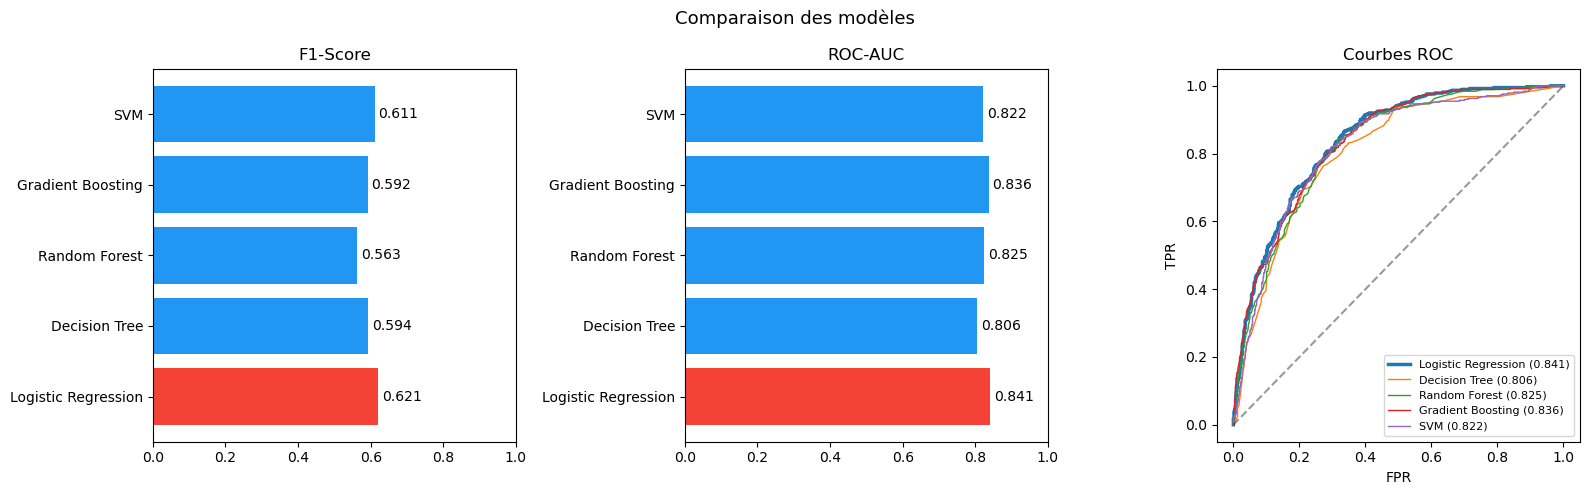

In [25]:
from sklearn.metrics import roc_curve

model_names = list(results.keys())
colors = ['#F44336' if m == best else '#2196F3' for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparaison des modèles', fontsize=13)

# F1
bars = axes[0].barh(model_names, [results[m]['f1'] for m in model_names], color=colors)
axes[0].set_xlim(0, 1)
axes[0].set_title('F1-Score')
for bar, val in zip(bars, [results[m]['f1'] for m in model_names]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# AUC
bars2 = axes[1].barh(model_names, [results[m]['roc_auc'] for m in model_names], color=colors)
axes[1].set_xlim(0, 1)
axes[1].set_title('ROC-AUC')
for bar, val in zip(bars2, [results[m]['roc_auc'] for m in model_names]):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Courbes ROC
for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    lw = 2.5 if name == best else 1
    axes[2].plot(fpr, tpr, linewidth=lw, label=f'{name} ({results[name]["roc_auc"]:.3f})')
axes[2].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[2].set_title('Courbes ROC')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Importance des variables

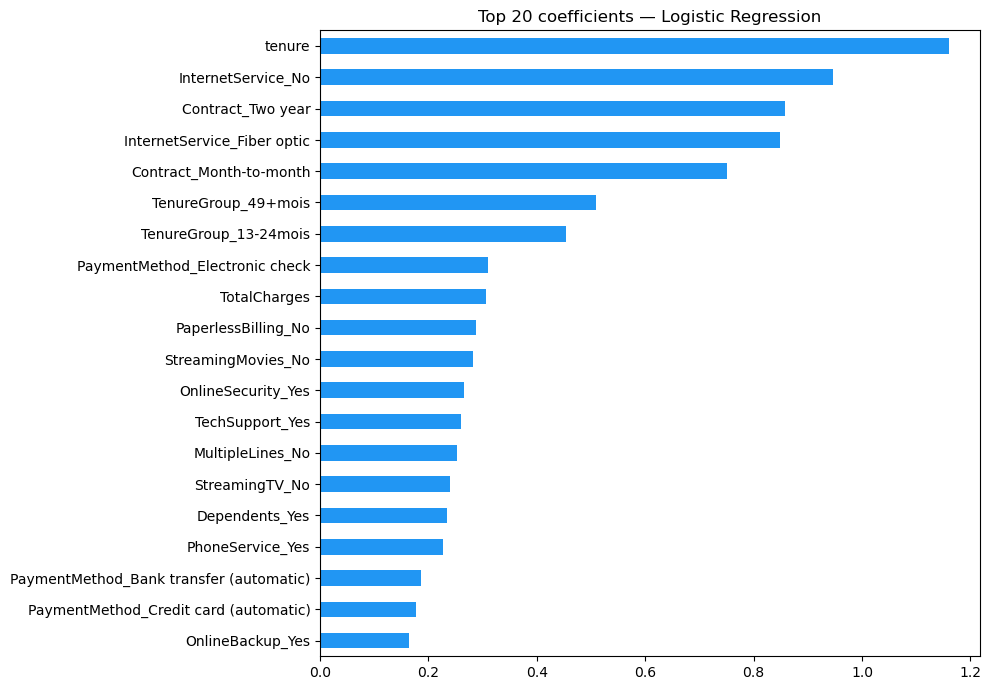


Top 10 variables :
tenure                            1.159597
InternetService_No                0.946028
Contract_Two year                 0.858401
InternetService_Fiber optic       0.849482
Contract_Month-to-month           0.750152
TenureGroup_49+mois               0.508751
TenureGroup_13-24mois             0.453501
PaymentMethod_Electronic check    0.309822
TotalCharges                      0.305758
PaperlessBilling_No               0.288488
dtype: float64


In [26]:
best_model = models[best]
ohe_features   = list(preprocessor.named_transformers_['cat']
                      .named_steps['ohe'].get_feature_names_out(cat_cols))
feature_names  = num_cols + ohe_features

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_names)
    imp.sort_values(ascending=False).head(20).plot(kind='barh', figsize=(10, 7), color='#2196F3')
    plt.gca().invert_yaxis()
    plt.title(f'Top 20 variables — {best}')
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    imp = pd.Series(np.abs(best_model.coef_[0]), index=feature_names)
    imp.sort_values(ascending=False).head(20).plot(kind='barh', figsize=(10, 7), color='#2196F3')
    plt.gca().invert_yaxis()
    plt.title(f'Top 20 coefficients — {best}')
    plt.tight_layout()
    plt.show()

print('\nTop 10 variables :')
print(imp.sort_values(ascending=False).head(10))